In [29]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path
import csv
import json
import subprocess
import re
from pathlib import Path

# Display settings: do not abbreviate DataFrame output
pd.set_option("display.max_rows", None)        # show all rows
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", None)           # don't wrap to fit console width
pd.set_option("display.max_colwidth", None)    # don't truncate column contents


In [30]:
BASE_DIR = Path("responses/sachs")
SUMMARY_CSV = BASE_DIR / "eval_summary.csv"

df = pd.read_csv(SUMMARY_CSV)

In [31]:
sachs_df = pd.read_csv("/u/chenyuen0103/ENCO/experiments/out/experiment1/sachs_summary.csv")


In [32]:
import pandas as pd

df = sachs_df.copy()
df = df[df["evaluated"] == 1].copy()

df["method"] = df["prompt_style"].map({
    "summary": "LLM-summary",
    "summary_joint": "LLM-summary_joint",
    "matrix": "LLM-matrix",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# optional: drop matrix context-fail rows
df = df[~((df["prompt_style"] == "matrix") & (df["context_exceeded_any"] == 1))].copy()

metric = "avg"  # or "consensus"
score_col = f"{metric}_f1"
err_col   = f"{metric}_shd"

# aggregate to one value per (method, anonymize, obs_n, int_n)
agg = (df.groupby(["method","anonymize","obs_n","int_n"], as_index=False)
         .agg(f1=(score_col,"mean"), shd=(err_col,"mean")))

# cells where summary_joint exists
joint_cells = agg.loc[agg["method"] == "LLM-summary_joint", ["anonymize","obs_n","int_n"]].drop_duplicates()

# keep only those cells for all methods
agg2 = agg.merge(joint_cells, on=["anonymize","obs_n","int_n"], how="inner")

macro = (agg2.groupby(["method","anonymize"], as_index=False)
           .agg(mean_f1=("f1","mean"), mean_shd=("shd","mean"), cells=("f1","count"))
           .sort_values(["anonymize","mean_shd"]))

macro


,method,anonymize,mean_f1,mean_shd,cells
0,LLM-matrix,0,0.158730,18.6,1
2,LLM-summary_joint,0,0.340667,27.7,2
1,LLM-matrix,1,0.410376,22.0,1
3,LLM-summary_joint,1,0.379319,32.2,2


In [37]:
from pathlib import Path
import pandas as pd

base = Path("./responses/sachs")
rows = []

for anon in [0, 1]:
    suffix = "_anon" if anon == 1 else ""
    for obs in [100, 200, 1000, 5000, 8000]:
        for inter in [0,  50, 100, 200, 500]:
            csv_name = f"responses_obs{obs}_int{inter}_shuf1_p5{suffix}_summary_joint_gpt-5-mini.csv"
            csv_path = base / csv_name
            summary_path = csv_path.with_suffix(csv_path.suffix + ".summary.json")
            rows.append({
                "anonymize": anon,
                "obs_n": obs,
                "int_n": inter,
                "csv_exists": csv_path.exists(),
                "summary_exists": summary_path.exists(),
                "csv": str(csv_path),
            })

status_df = pd.DataFrame(rows).sort_values(["anonymize", "obs_n", "int_n"]).reset_index(drop=True)
status_df


,anonymize,obs_n,int_n,csv_exists,summary_exists,csv
0,0,100,0,False,False,responses/sachs/responses_obs100_int0_shuf1_p5_summary_joint_gpt-5-mini.csv
1,0,100,50,False,False,responses/sachs/responses_obs100_int50_shuf1_p5_summary_joint_gpt-5-mini.csv
2,0,100,100,False,False,responses/sachs/responses_obs100_int100_shuf1_p5_summary_joint_gpt-5-mini.csv
3,0,100,200,False,False,responses/sachs/responses_obs100_int200_shuf1_p5_summary_joint_gpt-5-mini.csv
4,0,100,500,False,False,responses/sachs/responses_obs100_int500_shuf1_p5_summary_joint_gpt-5-mini.csv
5,0,200,0,False,False,responses/sachs/responses_obs200_int0_shuf1_p5_summary_joint_gpt-5-mini.csv
6,0,200,50,False,False,responses/sachs/responses_obs200_int50_shuf1_p5_summary_joint_gpt-5-mini.csv
7,0,200,100,False,False,responses/sachs/responses_obs200_int100_shuf1_p5_summary_joint_gpt-5-mini.csv
8,0,200,200,False,False,responses/sachs/responses_obs200_int200_shuf1_p5_summary_joint_gpt-5-mini.csv
9,0,200,500,False,False,responses/sachs/responses_obs200_int500_shuf1_p5_summary_joint_gpt-5-mini.csv


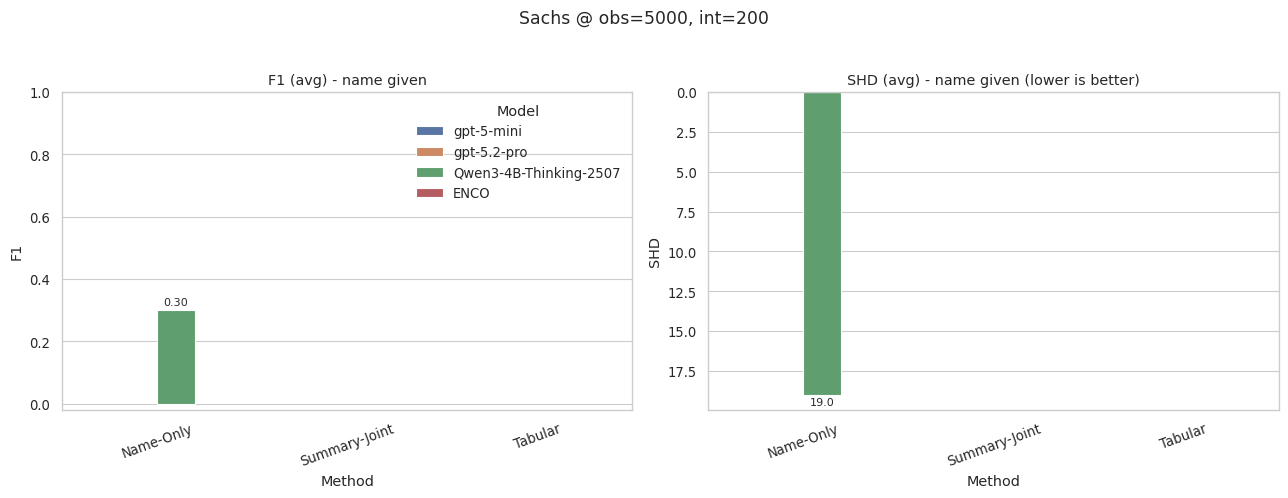

Saved: out/figures_pubready/sachs_obs5000_int200_name_given_avg_with_name_only.pdf


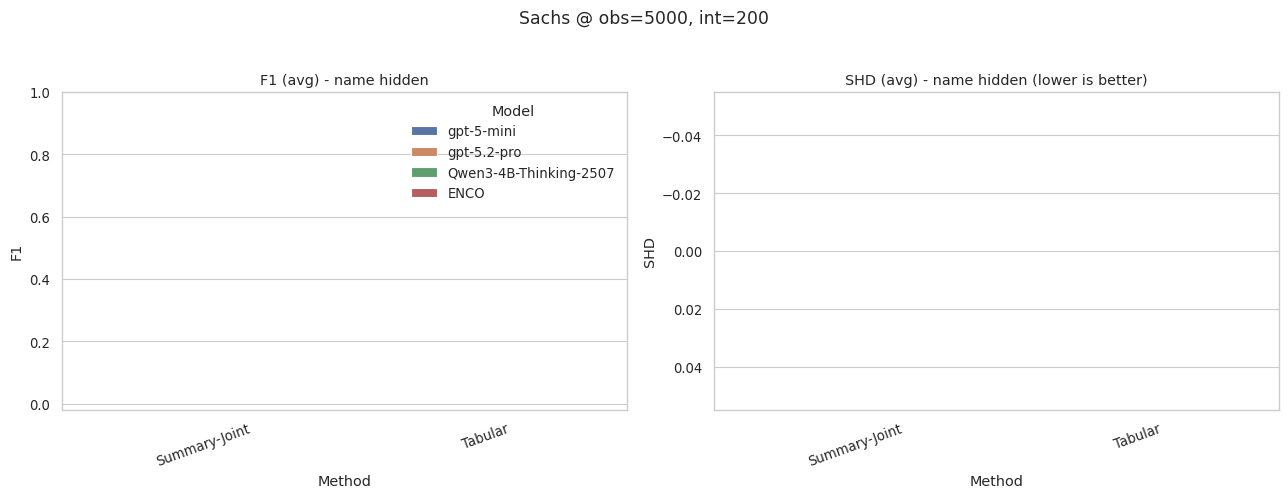

Saved: out/figures_pubready/sachs_obs5000_int200_name_hidden_avg_with_name_only.pdf


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
# summary_csv = "./out/experiment1/sachs_summary.csv"
summary_csv = "/u/chenyuen0103/ENCO/experiments/out/experiment1/sachs_summary.csv"

obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507"]
include_enco = True
out_dir = Path("./out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()

# map methods
df["method"] = df["prompt_style"].map({
    # "summary": "Summary",
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])


# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


In [35]:
df

,anonymize,avg_FN,avg_FP,avg_TN,avg_TP,avg_accuracy,avg_f1,avg_orientation_FN,avg_orientation_TP,avg_orientation_accuracy,avg_orientation_eval_pairs,avg_precision,avg_recall,avg_shd,brier,brier_skeleton,causal_rules,col_order,consensus_K,consensus_accuracy,consensus_f1,consensus_num_edges,consensus_orient_acc,consensus_precision,consensus_recall,consensus_shd,consensus_tau,context_exceeded_any,context_exceeded_by_error_rows,context_exceeded_by_tokens_rows,context_window,dataset,evaluated,format_ok_rows,format_rate,format_scored_rows,give_steps,given_edge_count,given_edge_frac,given_edges,int_n,is_names_only,model,nhd_ci95_high,nhd_ci95_low,nhd_consensus,nhd_iqr,nhd_mean,nhd_ratio_ci95_high,nhd_ratio_ci95_low,nhd_ratio_consensus,nhd_ratio_iqr,nhd_ratio_mean,nhd_ratio_sd,nhd_sd,num_pred_edges,num_rows,obs_n,prompt_style,prompt_tokens_max,prompt_tokens_mean,prompt_tokens_missing_rows,prompt_tokens_rows,response_csv,row_order,shuffles_per_graph,summary_json,true_num_edges,valid_rows,var_accuracy_ci95_high,var_accuracy_ci95_low,var_accuracy_iqr,var_accuracy_sd,var_f1_ci95_high,var_f1_ci95_low,var_f1_iqr,var_f1_sd,var_num_pred_edges_ci95_high,var_num_pred_edges_ci95_low,var_num_pred_edges_iqr,var_num_pred_edges_sd,var_precision_ci95_high,var_precision_ci95_low,var_precision_iqr,var_precision_sd,var_recall_ci95_high,var_recall_ci95_low,var_recall_iqr,var_recall_sd,var_shd_ci95_high,var_shd_ci95_low,var_shd_iqr,var_shd_sd,method
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,128000,sachs,1,0,NaN,0,0,0,NaN,0,NaN,1,Qwen3-4B-Thinking-2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,names_only,NaN,NaN,0,0,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_names_only_p5_Qwen3-4B-Thinking-2507.csv,random,NaN,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_names_only_p5_Qwen3-4B-Thinking-2507.csv.summary.json,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Name-Only
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,128000,sachs,1,0,0.0,5,0,0,NaN,0,200.0,0,Qwen3-4B-Thinking-2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0.0,matrix,72082.0,72082.0,0,5,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_anon_matrix_Qwen3-4B-Thinking-2507.csv,random,1.0,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_anon_matrix_Qwen3-4B-Thinking-2507.csv.summary.json,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tabular
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,128000,sachs,1,0,0.0,5,0,0,NaN,0,200.0,0,Qwen3-4B-Thinking-2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0.0,summary_joint,54360.0,54077.4,0,5,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_anon_summary_joint_Qwen3-4B-Thinking-2507.csv,random,1.0,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_anon_summary_joint_Qwen3-4B-Thinking-2507.csv.summary.json,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summary-Joint
5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,128000,sachs,1,0,0.0,5,0,0,NaN,0,200.0,0,Qwen3-4B-Thinking-2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0.0,matrix,50302.0,50289.0,0,5,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_matrix_Qwen3-4B-Thinking-2507.csv,random,1.0,/u/chenyuen0103/ENCO/experiments/responses/sachs/responses_obs0_int200_shuf1_p5_matrix_Qwen3-4B-Thinking-2507.csv.summary.json,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tabular
7,0,NaN,NaN,NaN,NaN,NaN,NaN,

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv = "./out/experiment1/diabetes_summary.csv"
obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507"]
include_enco = True
out_dir = Path("./out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()

# map methods
df["method"] = df["prompt_style"].map({
    # "summary": "Summary",
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])

# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


FileNotFoundError: [Errno 2] No such file or directory: './out/experiment1/diabetes_summary.csv'